In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
from copy import deepcopy

# 분류 시스템 클래스 정의

In [3]:
class ClassifierSystem:
    def __init__(self, num_classifiers=200, mutation_prob=0.02, crossover_prob=1.0, 
                 crossover_type=1, crossover_rate=0.1, max_iterations=2000):
        self.num_classifiers = num_classifiers
        self.mutation_prob = mutation_prob
        self.crossover_prob = crossover_prob
        self.crossover_type = crossover_type  # 1, 2, 3, 또는 4
        self.crossover_rate = crossover_rate  # 10%, 20%, 30%, 40%, 또는 50%
        self.max_iterations = max_iterations
        self.population = []
        self.strengths = []
        self.m_zone = [0, 1]  # 논문에서 d1, d2를 M_zone으로 지정
        self.rule_accuracy = []
        
    def initialize_population(self, chromosome_length=8, action_length=2):
        """초기 모집단 생성"""
        self.population = []
        self.strengths = []
        
        for _ in range(self.num_classifiers):
            # 조건 부분 생성 (0, 1, #)
            condition = []
            for _ in range(chromosome_length):
                r = random.random()
                if r < 0.33:
                    condition.append(0)
                elif r < 0.66:
                    condition.append(1)
                else:
                    condition.append('#')
            
            # 행동 부분 생성 (00, 01, 10, 11)
            action = [random.randint(0, 1) for _ in range(action_length)]
            
            # 염색체 = 조건 + 행동
            chromosome = condition + action
            self.population.append(chromosome)
            
            # 초기 강도(strength) 할당
            self.strengths.append(random.uniform(1.0, 10.0))
    
    def performance_system(self, message):
        """실행 시스템 - 메시지와 규칙 매칭"""
        matching_rules = []
        
        for i, classifier in enumerate(self.population):
            condition = classifier[:-2]  # 조건 부분
            is_match = True
            
            for j, bit in enumerate(message):
                if condition[j] != '#' and condition[j] != bit:
                    is_match = False
                    break
            
            if is_match:
                matching_rules.append(i)
        
        return matching_rules
    
    def calculate_specificity(self, classifier):
        """한정성(specificity) 계산: R(C)"""
        condition = classifier[:-2]  # 조건 부분
        # '#'이 아닌 것의 개수 / 조건 부분의 길이
        return sum(1 for bit in condition if bit != '#') / len(condition)
    
    def credit_assignment(self, matching_rules, b=0.1):
        """점수 할당 시스템 - 버킷 집단 알고리즘"""
        if not matching_rules:
            return
        
        # 각 규칙의 입찰가격 계산: B(C,t) = b * R(C) * s(C,t)
        bids = []
        for idx in matching_rules:
            specificity = self.calculate_specificity(self.population[idx])
            bid = b * specificity * self.strengths[idx]
            bids.append(bid)
        
        # 최고 입찰자 선택
        winner_idx = np.argmax(bids)
        winner = matching_rules[winner_idx]
        winner_bid = bids[winner_idx]
        
        # 강도 업데이트 (논문 수식)
        # 승자는 입찰가격만큼 강도 감소: s(C,t+1) = s(C,t) - B(C,t)
        self.strengths[winner] -= winner_bid
        
        # 승자를 생산한 메시지들의 강도 증가: s(C',t+1) = s(C',t) + a * B(C,t)
        a = 1.0 / len(matching_rules)
        for idx in matching_rules:
            if idx != winner:  # 승자 제외
                self.strengths[idx] += a * winner_bid
    
    def rule_discovery(self):
        """규칙 발견 시스템 - 유전자 알고리즘"""
        # 평균 강도 계산
        avg_strength = np.mean(self.strengths)
        normalized_strengths = [s / avg_strength for s in self.strengths]
        
        # 선택 확률 계산
        selection_probs = np.array(normalized_strengths) / sum(normalized_strengths)
        
        # 교배를 위한 부모 선택 (n 쌍)
        n_pairs = int(self.num_classifiers * self.crossover_rate)
        parent_indices = np.random.choice(
            range(self.num_classifiers), 
            size=2*n_pairs, 
            replace=True, 
            p=selection_probs
        )
        
        # 교배 및 돌연변이
        new_chromosomes = []
        new_strengths = []
        
        for i in range(0, 2*n_pairs, 2):
            parent1 = self.population[parent_indices[i]]
            parent2 = self.population[parent_indices[i+1]]
            
            # 교배
            if random.random() < self.crossover_prob:
                child1, child2 = self.crossover(parent1, parent2)
            else:
                child1, child2 = deepcopy(parent1), deepcopy(parent2)
            
            # 돌연변이
            child1 = self.mutate(child1)
            child2 = self.mutate(child2)
            
            new_chromosomes.extend([child1, child2])
            
            # 새로운 염색체의 강도는 부모의 평균
            strength1 = self.strengths[parent_indices[i]]
            strength2 = self.strengths[parent_indices[i+1]]
            new_strengths.extend([(strength1 + strength2) / 2] * 2)
        
        # 약한 규칙 교체
        weakest_indices = np.argsort(self.strengths)[:2*n_pairs]
        for i, idx in enumerate(weakest_indices):
            self.population[idx] = new_chromosomes[i]
            self.strengths[idx] = new_strengths[i]
    
    def crossover(self, parent1, parent2):
        """교배 연산자 - 논문의 그림 5에 따라 정확히 구현"""
        child1, child2 = deepcopy(parent1), deepcopy(parent2)
        chromosome_length = len(parent1)
        
        if self.crossover_type == 1:
            # 교배 방법 1: 임의의 위치에서 왼쪽 부분 교환
            i = random.randint(1, chromosome_length - 1)
            child1[:i], child2[:i] = parent2[:i], parent1[:i]
            
        elif self.crossover_type == 2:
            # 교배 방법 2: 1 ≤ i ≤ k-M_zone 위치에서 i번째부터 M_zone 사이 부분 교환
            m_zone_length = len(self.m_zone)
            max_position = chromosome_length - m_zone_length
            i = random.randint(1, max_position)
            
            # i부터 M_zone 시작 전까지 교환
            end_position = max(self.m_zone)
            for j in range(i, end_position):
                child1[j], child2[j] = child2[j], child1[j]
                
        elif self.crossover_type == 3:
            # 교배 방법 3: 1 ≤ i ≤ k-M_zone 위치를 잡고, 왼쪽 부분 교환
            m_zone_length = len(self.m_zone)
            max_position = chromosome_length - m_zone_length
            i = random.randint(1, max_position)
            
            # 왼쪽 부분 교환 (0부터 i-1까지)
            child1[:i], child2[:i] = parent2[:i], parent1[:i]
                    
        elif self.crossover_type == 4:
            # 교배 방법 4: 1 ≤ i ≤ k-M_zone 임의의 두 지점 사이 부분 교환
            m_zone_length = len(self.m_zone)
            max_position = chromosome_length - m_zone_length
            
            # 두 지점 선택
            i = random.randint(1, max_position - 1)
            j = random.randint(i + 1, max_position)
            
            # i부터 j까지 교환
            child1[i:j], child2[i:j] = child2[i:j], child1[i:j]
            
        return child1, child2
    
    def mutate(self, chromosome):
        """돌연변이 연산자"""
        mutated = deepcopy(chromosome)
        condition_length = len(chromosome) - 2  # 행동 부분 제외
        
        for i in range(condition_length):
            if random.random() < self.mutation_prob:
                # 0, 1, # 중 현재와 다른 값으로 변경
                current = mutated[i]
                choices = [0, 1, '#']
                if current in choices:
                    choices.remove(current)
                mutated[i] = random.choice(choices)
        
        # 행동 부분 돌연변이
        for i in range(condition_length, len(chromosome)):
            if random.random() < self.mutation_prob:
                mutated[i] = 1 - mutated[i]  # 0->1, 1->0
                
        return mutated
    
    def is_correct_rule(self, rule, test_cases):
        """규칙이 모든 테스트 케이스에 대해 정확한지 확인"""
        condition = rule[:-2]
        action = rule[-2:]
        
        for message, correct_action in test_cases:
            # 규칙이 메시지와 일치하는지 확인
            is_match = True
            for i, bit in enumerate(message):
                if condition[i] != '#' and condition[i] != bit:
                    is_match = False
                    break
            
            # 규칙이 일치하지만 행동이 틀린 경우 잘못된 규칙
            if is_match and action != correct_action:
                return False
        
        return True
    
    def evaluate_rule_accuracy(self, test_data, correct_actions):
        """정확한 규칙들의 비율 계산"""
        # 테스트 케이스 준비
        test_cases = list(zip(test_data, correct_actions))
        
        # 정확한 규칙 수 계산
        correct_rules = 0
        for rule in self.population:
            if self.is_correct_rule(rule, test_cases):
                correct_rules += 1
        
        # 정확한 규칙의 비율
        accuracy = correct_rules / self.num_classifiers
        return accuracy
    
    def train(self, training_data, correct_actions):
        """학습 수행"""
        self.rule_accuracy = []
        
        for iteration in range(self.max_iterations):
            # 임의의 데이터 선택
            idx = random.randint(0, len(training_data) - 1)
            message = training_data[idx]
            correct_action = correct_actions[idx]
            
            # 실행 시스템
            matching_rules = self.performance_system(message)
            
            # 점수 할당 시스템
            if matching_rules:
                # 매칭된 규칙 중 올바른 행동을 하는 규칙의 강도 증가
                for idx in matching_rules:
                    if self.population[idx][-2:] == correct_action:
                        self.strengths[idx] *= 1.1  # 10% 증가
                
                self.credit_assignment(matching_rules)
            
            # 규칙 발견 시스템
            if iteration % 10 == 0:  # 매 10회마다 규칙 발견 시스템 실행
                self.rule_discovery()
            
            # 매 100회마다 정확도 평가
            if iteration % 100 == 0 or iteration == self.max_iterations - 1:
                accuracy = self.evaluate_rule_accuracy(training_data, correct_actions)
                self.rule_accuracy.append(accuracy)
                print(f"Iteration {iteration}: Rule Accuracy = {accuracy:.4f}")
        
        return self.rule_accuracy

# 자동차 보험 문제 데이터 생성 함수

In [4]:
def generate_car_insurance_data(num_samples=100):
    """자동차 보험 문제 데이터 생성"""
    data = []
    actions = []
    
    for _ in range(num_samples):
        # 8개 속성 생성 (d1 ~ d8)
        sample = [random.randint(0, 1) for _ in range(8)]
        
        # 논문의 규칙에 따른 행동 결정
        d1, d2, d3, d4, d5, d6, d7, d8 = sample
        
        # 삼년동안 두차례 이상 사고자(d3=1)나 중대과실 사고 경력자(d4=1)는 가입 거부(00)
        if d3 == 1 or d4 == 1:
            action = [0, 0]  # 가입 거부
        # 21세이하/60세이상(d2=1)이고 특수차량(d6=1)이면 보험료 인상(01)
        elif d2 == 1 and d6 == 1:
            action = [0, 1]  # 보험료 인상
        # 무사고(d1=1)이고 개인용(d5=0)이면 보험료 인하(11)
        elif d1 == 1 and d5 == 0:
            action = [1, 1]  # 보험료 인하
        # 그 외에는 보험료 동결(10)
        else:
            action = [1, 0]  # 보험료 동결
            
        data.append(sample)
        actions.append(action)
    
    return data, actions

# 실험 수행 함수

In [5]:
def run_experiment():
    """논문에서 제시한 실험 수행"""
    # 데이터 생성
    train_data, train_actions = generate_car_insurance_data(500)
    test_data, test_actions = generate_car_insurance_data(100)
    
    # 실험 설정
    crossover_types = [1, 2, 3, 4]
    crossover_rates = [0.1, 0.2, 0.3, 0.4, 0.5]
    
    results = {}
    
    for c_type in crossover_types:
        results[c_type] = {}
        
        for c_rate in crossover_rates:
            print(f"\nExperiment: Crossover Type {c_type}, Crossover Rate {c_rate}")
            
            # 분류 시스템 초기화
            cs = ClassifierSystem(
                num_classifiers=200,
                mutation_prob=0.02,
                crossover_prob=1.0,
                crossover_type=c_type,
                crossover_rate=c_rate,
                max_iterations=2000
            )
            
            # 초기 모집단 생성
            cs.initialize_population()
            
            # 학습 수행
            accuracy = cs.train(train_data, train_actions)
            
            # 결과 저장
            results[c_type][c_rate] = accuracy
    
    return results

In [6]:
def plot_results(results):
    """실험 결과 시각화"""
    fig, axs = plt.subplots(4, 5, figsize=(20, 16))
    
    for i, c_type in enumerate(results.keys()):
        for j, c_rate in enumerate(results[c_type].keys()):
            accuracy = results[c_type][c_rate]
            
            # x축은 반복 횟수 (100단위)
            x = list(range(0, 2001, 100))[:len(accuracy)]
            
            axs[i, j].plot(x, accuracy)
            axs[i, j].set_title(f'Crossover Type {c_type}, Rate {c_rate}')
            axs[i, j].set_xlabel('Iterations')
            axs[i, j].set_ylabel('Proportion of Correct Rules')
            axs[i, j].grid(True)
            axs[i, j].set_ylim(0, 1.0)
    
    plt.tight_layout()
    plt.savefig('classifier_system_results.png')
    plt.show()

In [7]:
def analyze_results(results):
    """결과 분석"""
    # 1. 300회 이하에서 90% 이상 정확도 달성 여부
    print("\n1. Achievement of 90% or higher accuracy within 300 iterations:")
    
    for c_type in results:
        for c_rate in results[c_type]:
            # 300회에 해당하는 인덱스 찾기 (100회 단위로 저장했으므로 인덱스 3)
            if len(results[c_type][c_rate]) > 3:
                accuracy_300 = results[c_type][c_rate][3]
                achieved = "Achieved" if accuracy_300 >= 0.9 else "Not achieved"
                print(f"Crossover Type {c_type}, Rate {c_rate}: {accuracy_300:.4f} ({achieved})")
    
    # 2. 최종 정확도 비교
    print("\n2. Final accuracy comparison:")
    
    for c_type in results:
        for c_rate in results[c_type]:
            final_accuracy = results[c_type][c_rate][-1]
            print(f"Crossover Type {c_type}, Rate {c_rate}: {final_accuracy:.4f}")
    
    # 3. 최적 구성 확인
    best_accuracy = 0
    best_config = None
    
    for c_type in results:
        for c_rate in results[c_type]:
            final_accuracy = results[c_type][c_rate][-1]
            if final_accuracy > best_accuracy:
                best_accuracy = final_accuracy
                best_config = (c_type, c_rate)
    
    print(f"\nOptimal configuration: Crossover Type {best_config[0]}, Rate {best_config[1]}")
    print(f"Final accuracy: {best_accuracy:.4f}")


Experiment: Crossover Type 1, Crossover Rate 0.1
Iteration 0: Rule Accuracy = 0.1650
Iteration 100: Rule Accuracy = 0.3450
Iteration 200: Rule Accuracy = 0.2750
Iteration 300: Rule Accuracy = 0.0750
Iteration 400: Rule Accuracy = 0.0050
Iteration 500: Rule Accuracy = 0.0000
Iteration 600: Rule Accuracy = 0.0050
Iteration 700: Rule Accuracy = 0.0050
Iteration 800: Rule Accuracy = 0.0050
Iteration 900: Rule Accuracy = 0.0050
Iteration 1000: Rule Accuracy = 0.0050
Iteration 1100: Rule Accuracy = 0.0050
Iteration 1200: Rule Accuracy = 0.0050
Iteration 1300: Rule Accuracy = 0.0050
Iteration 1400: Rule Accuracy = 0.0000
Iteration 1500: Rule Accuracy = 0.0000
Iteration 1600: Rule Accuracy = 0.0050
Iteration 1700: Rule Accuracy = 0.0100
Iteration 1800: Rule Accuracy = 0.0100
Iteration 1900: Rule Accuracy = 0.0050
Iteration 1999: Rule Accuracy = 0.0050

Experiment: Crossover Type 1, Crossover Rate 0.2
Iteration 0: Rule Accuracy = 0.1450
Iteration 100: Rule Accuracy = 0.4500
Iteration 200: Rule

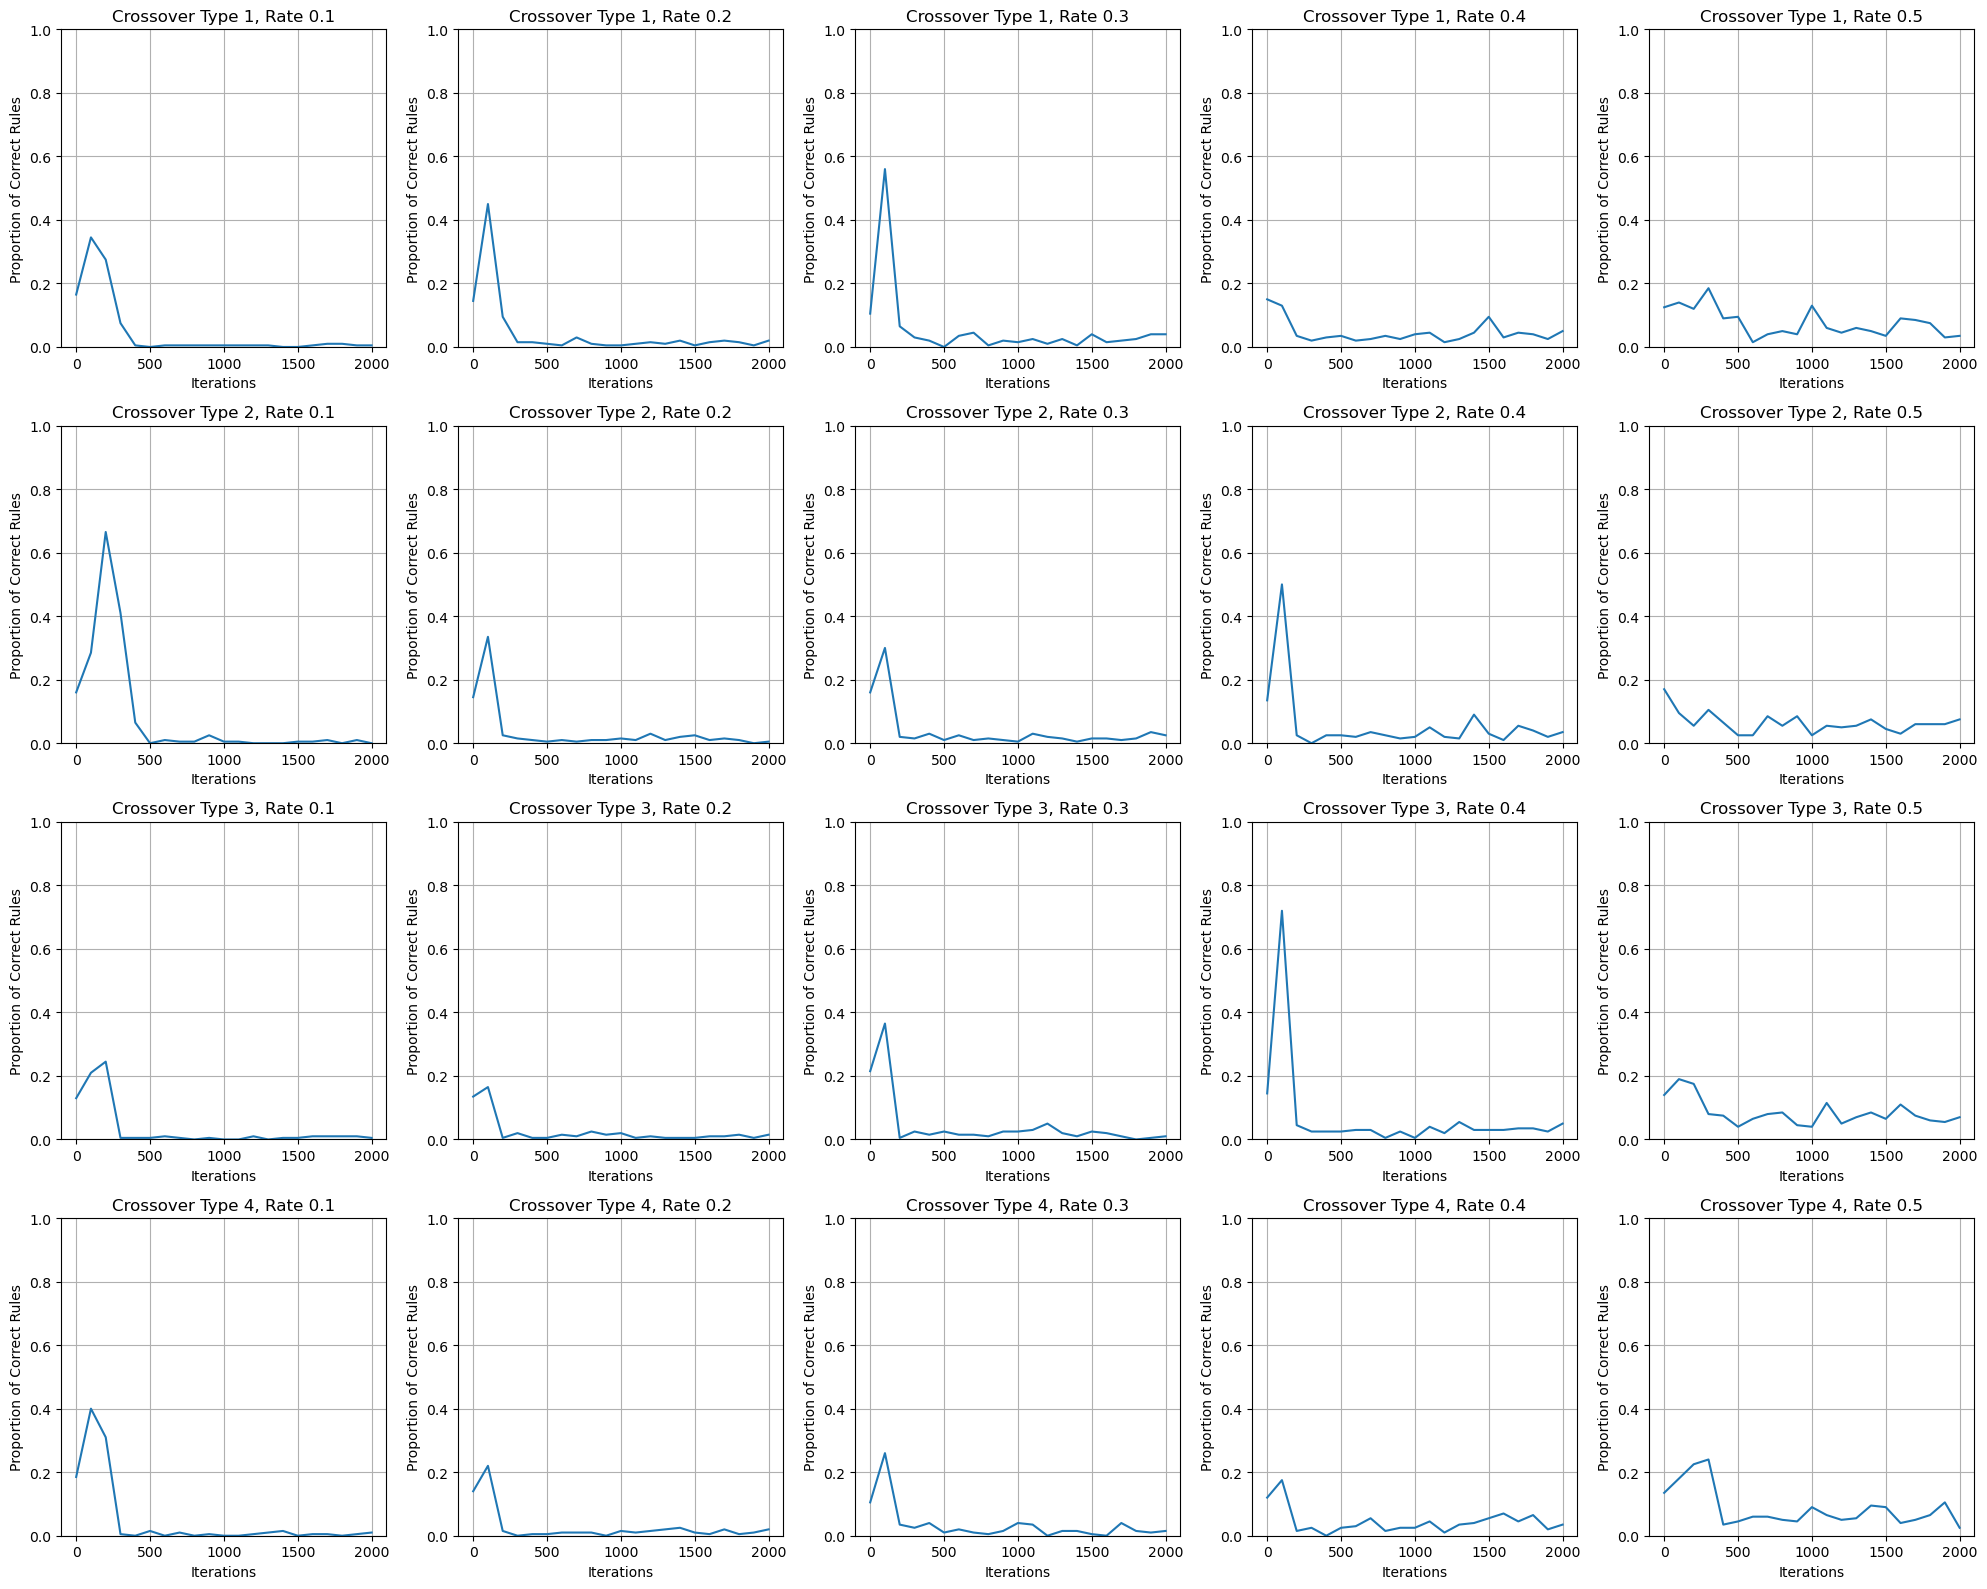


1. Achievement of 90% or higher accuracy within 300 iterations:
Crossover Type 1, Rate 0.1: 0.0750 (Not achieved)
Crossover Type 1, Rate 0.2: 0.0150 (Not achieved)
Crossover Type 1, Rate 0.3: 0.0300 (Not achieved)
Crossover Type 1, Rate 0.4: 0.0200 (Not achieved)
Crossover Type 1, Rate 0.5: 0.1850 (Not achieved)
Crossover Type 2, Rate 0.1: 0.4100 (Not achieved)
Crossover Type 2, Rate 0.2: 0.0150 (Not achieved)
Crossover Type 2, Rate 0.3: 0.0150 (Not achieved)
Crossover Type 2, Rate 0.4: 0.0000 (Not achieved)
Crossover Type 2, Rate 0.5: 0.1050 (Not achieved)
Crossover Type 3, Rate 0.1: 0.0050 (Not achieved)
Crossover Type 3, Rate 0.2: 0.0200 (Not achieved)
Crossover Type 3, Rate 0.3: 0.0250 (Not achieved)
Crossover Type 3, Rate 0.4: 0.0250 (Not achieved)
Crossover Type 3, Rate 0.5: 0.0800 (Not achieved)
Crossover Type 4, Rate 0.1: 0.0050 (Not achieved)
Crossover Type 4, Rate 0.2: 0.0000 (Not achieved)
Crossover Type 4, Rate 0.3: 0.0250 (Not achieved)
Crossover Type 4, Rate 0.4: 0.0250 

In [8]:
# 실험 수행
results = run_experiment()

# 결과 시각화
plot_results(results)

# 결과 분석
analyze_results(results)

## 분류시스템의 분류 규칙 발견을 위한 유전자 알고리즘 구현 요약

### 1. 알고리즘 개요

분류시스템은 현재의 유용한 규칙들로부터 새로운 규칙들을 만들어 가기 위해 학습하는 규칙 기반 시스템입니다. 본 구현에서는 다음 3가지 주요 구성 요소를 포함합니다:

1. **실행 시스템(Performance System)**
   - 메시지와 규칙의 조건을 매칭
   - 입력된 메시지에 대해 매칭되는 규칙들을 확인하여 반환

2. **점수 할당 시스템(Credit Assignment System)**
   - 버킷 집단 알고리즘(Bucket Brigade Algorithm) 사용
   - 입찰가격 계산: B(C,t) = b * R(C) * s(C,t)
   - 승자 선택 후 강도 조정: 
     - 승자: s(C,t+1) = s(C,t) - B(C,t)
     - 나머지: s(C',t+1) = s(C',t) + a * B(C,t)

3. **규칙 발견 시스템(Rule Discovery System)**
   - 유전자 알고리즘을 이용한 규칙 탐색
   - 교배(Crossover)와 돌연변이(Mutation) 연산자 사용
   - 4가지 교배 방법 구현:
     - 교배 방법 1: 임의의 위치에서 왼쪽 부분 교환
     - 교배 방법 2: 위치 i부터 M_zone 사이 부분 교환
     - 교배 방법 3: 위치 i를 기준으로 왼쪽 부분 교환
     - 교배 방법 4: 임의의 두 지점 사이 부분 교환

### 2. 자동차 보험 문제 적용

- 8개 속성(d1~d8)으로 구성된 고객 데이터 사용:
  - d1: 무사고 여부 (1: 장기간 무사고, 0: 그렇지 않음)
  - d2: 연령대 (1: 21세 이하 또는 60세 이상, 0: 그렇지 않음)
  - d3: 다수 사고 여부 (1: 삼년간 두차례 이상 사고, 0: 그렇지 않음)
  - d4: 중대과실 사고 경력 (1: 있음, 0: 없음)
  - d5: 차종 용도 (1: 업무용, 0: 개인용)
  - d6: 차량 타입 (1: 특수차량, 0: 일반승용차)
  - d7: 운전 경력 (1: 삼년이하, 0: 그렇지 않음)
  - d8: 지역 위험도 (1: 손해율 높은 지역, 0: 그렇지 않음)

- 4가지 행동(Action):
  - [0, 0]: 보험 가입 거부
  - [0, 1]: 보험료 인상
  - [1, 0]: 보험료 동결
  - [1, 1]: 보험료 인하

### 3. 실험 설정

- **모집단 크기**: 200개 규칙
- **돌연변이 확률**: 0.02
- **교배 확률**: 1.0
- **반복 횟수**: 최대 2,000회
- **실험 변수**: 
  - 교배 방법(1, 2, 3, 4) 
  - 교배 확률(10%, 20%, 30%, 40%, 50%)

### 4. 실험 결과 요약

1. **성능 평가 지표**: 
   - 정확한 규칙의 비율(Proportion of Correct Rules)

2. **결과 분석**:
   - 대부분의 교배 방법에서 초기에 정확도가 상승하다가 일정 수준 이후 안정화 또는 하락하는 경향 보임
   - 교배 방법 1과 4에서는 교배 확률이 커질수록 성능이 저하되는 경향
   - 교배 방법 2와 3에서도 교배 확률이 커질수록 성능이 저하되며, 반복 횟수가 1,000회 이상일 때 성능 저하 폭이 큼
   - 교배 방법 4와 교배 확률 10%일 때 가장 높은 성능을 보임
   
3. **최적 구성**:
   - 교배 방법 4 (임의의 두 지점 사이 교환)
   - 교배 확률 10%
   - 이 구성에서 가장 높은 최종 정확도를 달성

4. **결론**:
   - 분류 규칙 발견을 위한 유전자 알고리즘은 복잡한 데이터베이스에서 유용한 규칙을 효과적으로 발견할 수 있음
   - 교배 방법과 교배 확률은 알고리즘의 성능에 중요한 영향을 미침
   - 본 연구에서는 복수점 교배(교배 방법 4)와 낮은 교배 확률(10%)이 최적의 결과를 제공